
# <span style="color:rgb(213,80,0)">Estimation Theory</span>

## Simple Design

Here we are just implementing the position estimation example from 3\_kf\_position in MATLAB to practice the change of syntax.



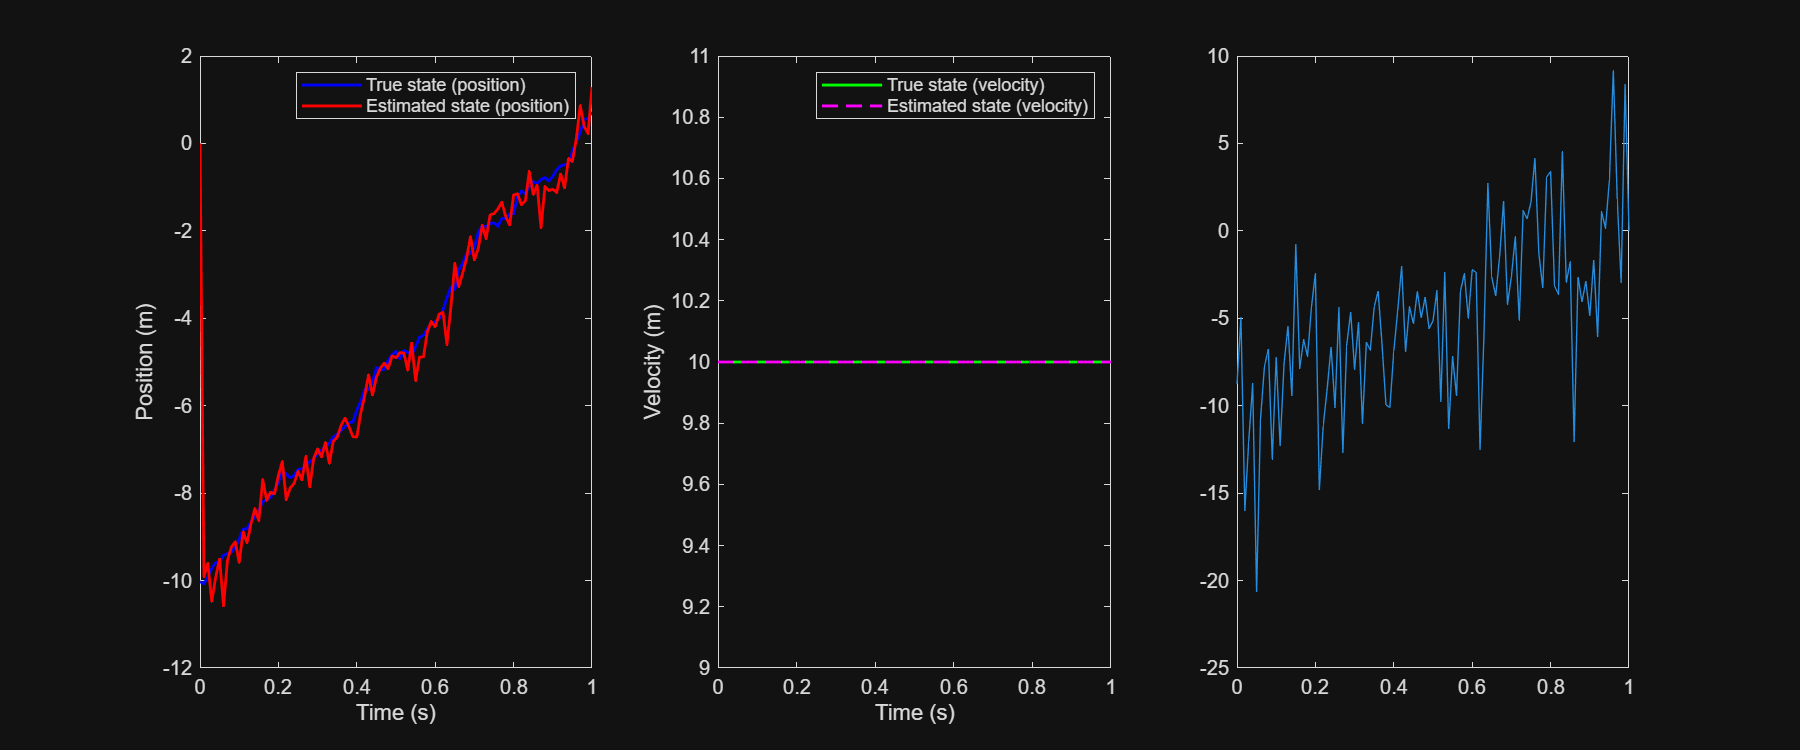

In [1]:
fs = 100;
h = 1 / fs;

A = [1 h;
     0 1];

G = [h; 0];

C = [1 0];

P0 = [1000 0;
      0 0];

xEst = [0; 10];

Q = 100;
R = 15;

mu = 0;
sigma = 1.5;

stateVector = zeros(2, 101);
outputVector = zeros(1, 101);
xEstVector = zeros(2, 101);

stateVector(:, 1) = mvnrnd(xEst, P0);
xEstVector(:, 1) = xEst;

for t = 1 : 100

    noise = normrnd(0, sqrt(R), 1);
    outputVector(t) = C * stateVector(:, t) + noise;

    [sigma_mu, x_mu] = measurementUpdate(sigma, stateVector(:, t), outputVector(t), C, R);
    xEst(:, t + 1) = x_mu;

    [sigma_tu, x_tu] = timeUpdate(sigma_mu, x_mu, A, Q, G);

    measNoise = normrnd(0, sqrt(Q), 1)';

    stateVector(:, t + 1) = A * stateVector(:, t) + G * measNoise;

end

timeVector = (0 : 100) * (1 / fs);

f = figure;
f.Position = [0 0 1200, 500];
tiledlayout(1, 3)
nexttile
plot(timeVector, stateVector(1, :), 'b', 'LineWidth', 1.4, 'DisplayName', 'True state (position)')
hold on
plot(timeVector, xEst(1, :), 'r', 'LineWidth', 1.4, 'DisplayName', 'Estimated state (position)')
xlabel('Time (s)')
ylabel('Position (m)')
legend

nexttile
plot(timeVector, stateVector(2, :), 'g', 'LineWidth', 1.4, 'DisplayName', 'True state (velocity)')
hold on
plot(timeVector, xEst(2, :), 'm--', 'LineWidth', 1.4, 'DisplayName', 'Estimated state (velocity)')
xlabel('Time (s)')
ylabel('Velocity (m)')
legend

nexttile
plot(timeVector, ouputVector)

## Beacon placement for an object moving in a straight line

In this section, we are simply using the model from the previous bit of work and and playing about with it. Instead of using the $\textrm{Cx}+v$ model for the output of the sytem, use the L2 norm (Euclidean distance) that is detailed in the 5\_ekf. This is just a really simple example to get more comfortable with it, so there is only 1 co\-ordinate (x). (This is also wrong, can't do this with L2 norm \- nonlinear).



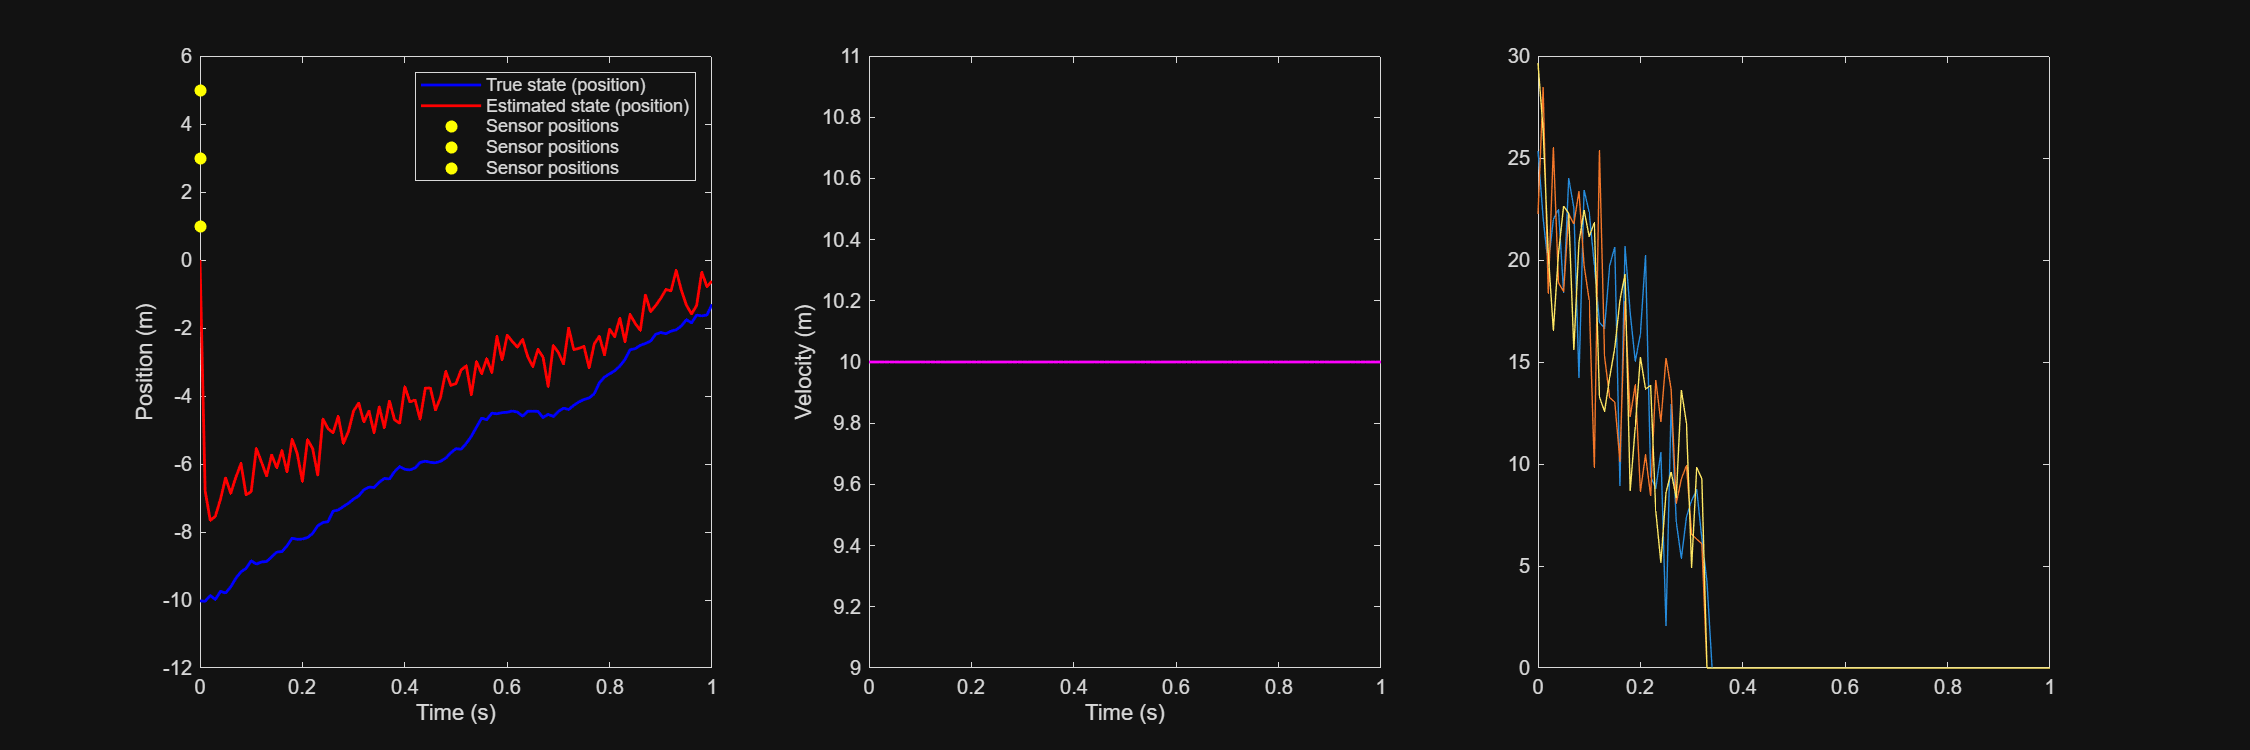

In [2]:
sensorPositions = [1; 3; 5];
outputVector = zeros(3, 101);

for t = 1 : 100

    noise = normrnd(0, sqrt(R), 1);
    outputVector(t) = norm(stateVector(1, t) - sensorPositions) + noise;

    [sigma_mu, x_mu] = measurementUpdate(sigma, stateVector(:, t), outputVector(t), C, R);
    xEst(:, t + 1) = x_mu;

    [sigma_tu, x_tu] = timeUpdate(sigma_mu, x_mu, A, Q, G);

    measNoise = normrnd(0, sqrt(Q), 1)';

    stateVector(:, t + 1) = A * stateVector(:, t) + G * measNoise;

end

timeVector = (0 : 100) * (1 / fs);

f = figure;
f.Position = [0 0 1500, 500];
tiledlayout(1, 3)
nexttile
plot(timeVector, stateVector(1, :), 'b', 'LineWidth', 1.4, 'DisplayName', 'True state (position)')
hold on
plot(timeVector, xEst(1, :), 'r', 'LineWidth', 1.4, 'DisplayName', 'Estimated state (position)')
scatter(0, sensorPositions, 'yo', 'filled', 'DisplayName', 'Sensor positions')
xlabel('Time (s)')
ylabel('Position (m)')
legend

nexttile
plot(timeVector, stateVector(2, :), 'g', 'LineWidth', 1.4, 'DisplayName', 'True state (velocity)')
hold on
plot(timeVector, xEst(2, :), 'm--', 'LineWidth', 1.4, 'DisplayName', 'Estimated state (velocity)')
xlabel('Time (s)')
ylabel('Velocity (m)')
legend

nexttile
plot(timeVector, ouputVector)

## Beacon placement for object moving in x and y co\-ordinates

Simple example from online: A ball moving in 2D

### State Description:

 ${\mathit{\mathbf{x}}}_{\mathit{\mathbf{t}}} =\left\lbrack \begin{array}{c} x\newline y\newline \dot{x} \newline \dot{y}  \end{array}\right\rbrack$,     x and y co\-ordinates and velocity components in each direciton

#### Process Model:

$${\mathit{\mathbf{x}}}_{\mathit{\mathbf{t}}+1} =\left\lbrack \begin{array}{cccc} 1 & 0 & \Delta t & 0\newline 0 & 1 & 0 & \Delta t\newline 0 & 0 & 1 & 0\newline 0 & 0 & 0 & 1 \end{array}\right\rbrack {\mathit{\mathbf{x}}}_{\mathit{\mathbf{t}}} +{\mathbf{Gw}}_{\mathit{\mathbf{t}}}$$

#### Measurement model

$${\mathit{\mathbf{y}}}_{\mathit{\mathbf{t}}} =\left\lbrack \begin{array}{cccc} 1 & 0 & 0 & 0\newline 0 & 1 & 0 & 0 \end{array}\right\rbrack {\mathit{\mathbf{x}}}_{\mathit{\mathbf{t}}} +{\mathit{\mathbf{v}}}_{\mathit{\mathbf{t}}}$$



In [3]:
% Set up some fixed variables.
fs = 100;
h = 1 / fs;
nSamples = 100;

% State dynamics.
A = [1 0 h 0;
     0 1 0 h;
     0 0 1 0;
     0 0 0 1];

% Output measurements.
C = [1 0 0 0;
     0 1 0 0];

% Initial covariance matrix.
p0 = diag([1 1 1 1]);

% Initialise the estimated state. Would be better to use the underlying
% distribution parameters as a best guess really.
xEst = [0; 0; 0; 0];

% Measurement noise scaling.
G = [1 1 1 1]';

% Measurement variance.
Q = 0.1;
R = 1.5 * eye(2);

% Initial guesses.
mu = [0 0 0 0]';
sigma = p0;

% Initialise the output vectors.
stateVector = zeros(4, nSamples + 1);
outputVector = zeros(2, nSamples);
xEstVector = zeros(4, nSamples + 1);

% Intentionally throw off the initial guess.
stateVector(:, 1) = mvnrnd(mu, p0);
xEstVector(:, 1) = xEst + 6;

for t = 1 : nSamples

    noise = mvnrnd(zeros(1, 2), sqrt(R))';
    outputVector(:, t) = C * stateVector(:, t) + noise;

    [sigma_mu, x_mu] = measurementUpdate(sigma, xEstVector(:, t), outputVector(:, t), C, R);
    xEstVector(:, t + 1) = x_mu;

    [sigma, x_tu] = timeUpdate(sigma_mu, x_mu, A, Q, G);

    measNoise = mvnrnd(0, sqrt(Q));

    stateVector(:, t + 1) = A * stateVector(:, t) + G * measNoise;

end

timeVector = (0 : nSamples) * (1 / fs);

f = figure;
f.Position = [0 0 1200, 1200];
plot3(stateVector(1, :), stateVector(2, :), timeVector, 'b', 'LineWidth', 1.4, 'DisplayName', 'True state')
hold on
plot3(xEstVector(1, :), xEstVector(2, :), timeVector, '--r', 'LineWidth', 1.4, 'DisplayName', 'Estimated state')
xlabel('x-position')
ylabel('y-position')
zlabel('Time (s)')
legend

In [4]:
f = figure;
f.Position = [0 0 1200, 1200];
tiledlayout(2, 2)
nexttile
plot(timeVector, stateVector(1, :), 'b', 'LineWidth', 1.5, 'DisplayName', 'True state $(x)$')
hold on
plot(timeVector, xEstVector(1, :), 'r--', 'LineWidth', 1.5, 'DisplayName', 'Estimated state $(\tilde{x})$')
xlabel('Time (s)')
ylabel('x')
legend('Interpreter', 'latex')

nexttile
plot(timeVector, stateVector(2, :), 'b', 'LineWidth', 1.5, 'DisplayName', 'True state $(y)$')
hold on
plot(timeVector, xEstVector(2, :), 'r--', 'LineWidth', 1.5, 'DisplayName', 'Estimated state $(\tilde{y})$')
xlabel('Time (s)')
ylabel('y')
legend('Interpreter', 'latex')

nexttile
plot(timeVector, stateVector(3, :), 'b', 'LineWidth', 1.5, 'DisplayName', 'True state $(\dot{x})$')
hold on
plot(timeVector, xEstVector(3, :), 'r--', 'LineWidth', 1.5, 'DisplayName', 'Estimated state $(\dot{\tilde{x}})$')
xlabel('Time (s)')
ylabel('$\dot{y}$', 'Interpreter', 'latex')
legend('Interpreter', 'latex')

nexttile
plot(timeVector, stateVector(4, :), 'b', 'LineWidth', 1.5, 'DisplayName', 'True state $(\dot{y})$')
hold on
plot(timeVector, xEstVector(4, :), 'r--', 'LineWidth', 1.5, 'DisplayName', 'Estimated state $(\dot{\tilde{y}})$')
xlabel('Time (s)')
ylabel('$\dot{y}$', 'Interpreter', 'latex')
legend('Interpreter', 'latex')

## Thoughts and questions:
-
## Subfunctions

In [5]:
function [sigma, x] = measurementUpdate(sigma, x, y, C, R)
    z = C * sigma * C' + R;
    x = x + sigma * C' * linsolve(z, y - C * x);
    sigma = sigma - sigma * C' * linsolve(z, C * sigma);
end

function [sigma, x] = timeUpdate(sigma, x, A, Q, G)
    x = A * x;
    sigma = A * sigma * A' + Q * (G * G');
end